# Estudo Dirigido 1 - Ciencia de Dados
## Alunos: Rafael Grabowski de Lima, Iuker Santos, Gabriel Bauer, Murilo Henrique Baruffi

#### Importando bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline

SEMENTE = 42

#### Importando Dataset

In [2]:

dataset = pd.read_csv('apples_and_oranges.csv')
dataset.head()


,Weight,Size,Class
0,69,4.39,orange
1,69,4.21,orange
2,65,4.09,orange
3,72,5.85,apple
4,67,4.70,orange


### Análise Exploratória dos Dados

In [3]:
dataset.info()
# O dataset tem 2 features (weight e size) que ajudam a identificar ou prever, 3 atributos
# possui 1 label que seria Class (apple || orange)
# a tabela não tem dados vazios
# não existe nenhum registro duplicado

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  40 non-null     int64  
 1   Size    40 non-null     float64
 2   Class   40 non-null     str    
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 KB


In [4]:
dataset.describe()
# os dados necessitam de padronzação, já que KNN é sensível à escala dos dados, mesmo o dataset tendo duas features.

,Weight,Size
count,40.000000,40.000000
mean,70.200000,4.922750
std,3.039906,0.590063
min,65.000000,4.010000
25%,68.000000,4.360000
50%,70.000000,4.930000
75%,73.000000,5.472500
max,75.000000,5.850000


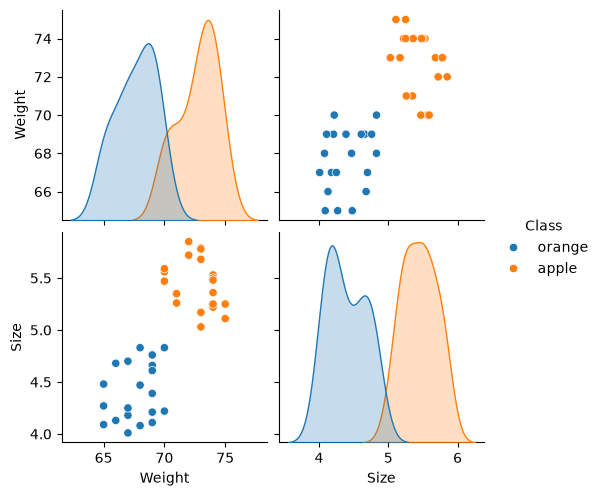

In [5]:
sns.pairplot(dataset, hue='Class')
# agrupando é possivel identificar que as variáveis escolhidas têm capacidade de distinguir as classes.
# quando analisamos peso e tamanho. Essa separação indica que
# essas variáveis são adequadas para treinar um classificador.

### Separando Dados e Treinando Modelo

#### Separar variáveis e classe

In [6]:
# Weight e Size serão usados para prever a classe da fruta
X = dataset[['Weight', 'Size']]

# Class contém a resposta esperada: apple ou orange
y = dataset['Class']

#### Dividir os dados entre treino e teste

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,      # 25% dos dados serão usados para teste
    random_state=SEMENTE,     # permite reproduzir a mesma divisão
    stratify=y           # mantém a proporção de maçãs e laranjas
)

print(f'Dados de treinamento: {len(X_train)}')
print(f'Dados de teste: {len(X_test)}')

# O conjunto de treinamento ensina o modelo. O conjunto de teste fica separado
# para avaliar se ele consegue classificar dados que não utilizou no aprendizado.

Dados de treinamento: 30
Dados de teste: 10


#### Criar o modelo KNN

In [8]:
modelo_knn = Pipeline([
    # Padroniza peso e tamanho usando apenas os dados de treinamento
    ('padronizacao', StandardScaler()),

    # Classifica a fruta considerando os cinco vizinhos mais próximos
    ('knn', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance'
    ))
])
# O parâmetro weights='distance' faz com que os vizinhos mais próximos tenham maior influência na classificação.

#### treinar o modelo


In [9]:

modelo_knn.fit(X_train, y_train)

print('Modelo KNN treinado com sucesso!')

Modelo KNN treinado com sucesso!


#### Testando Modelo

In [10]:
y_pred = modelo_knn.predict(X_test)

comparacao = X_test.copy()
comparacao['Classe_real'] = y_test
comparacao['Classe_prevista'] = y_pred

comparacao

,Weight,Size,Classe_real,Classe_prevista
11,70,5.47,apple,apple
19,74,5.50,apple,apple
22,69,4.61,orange,orange
28,74,5.25,apple,apple
34,68,4.83,orange,orange
30,73,5.78,apple,apple
18,67,4.18,orange,orange
0,69,4.39,orange,orange
1,69,4.21,orange,orange
12,74,5.53,apple,apple


In [11]:
print(y_test)

11     apple
19     apple
22    orange
28     apple
34    orange
30     apple
18    orange
0     orange
1     orange
12     apple
Name: Class, dtype: str


#### Calcular acuracia

In [12]:
acuracia = accuracy_score(y_test, y_pred)

print(f'Acurácia do modelo KNN: {acuracia:.2%}')

Acurácia do modelo KNN: 100.00%


#### Matriz de confusão

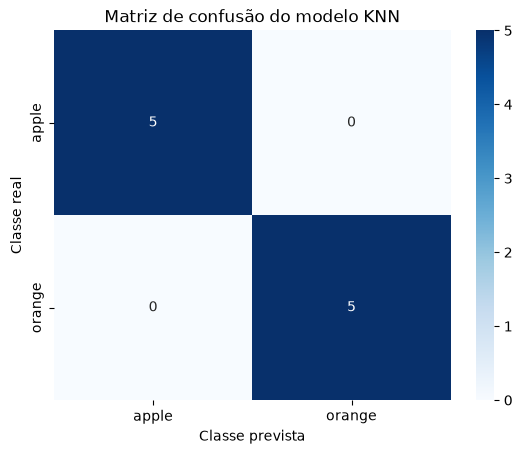

In [13]:
classes = ['apple', 'orange']

matriz = confusion_matrix(
    y_test,
    y_pred,
    labels=classes
)
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title('Matriz de confusão do modelo KNN')
plt.xlabel('Classe prevista')
plt.ylabel('Classe real')
plt.show()

#### Testando Valores novos ja padronizados

In [14]:
novas_frutas = pd.DataFrame({
    'Weight': [68.5, 72.5, 74.5, 66.5],
    'Size': [4.65, 5.25, 5.70, 4.15]
})
novas_frutas['Classe_prevista'] = modelo_knn.predict(novas_frutas)

novas_frutas

,Weight,Size,Classe_prevista
0,68.5,4.65,orange
1,72.5,5.25,apple
2,74.5,5.70,apple
3,66.5,4.15,orange
